# Sentiment Analysis


In [187]:
import json
from pathlib import Path
from collections import Counter
import nltk
import matplotlib.pyplot as plt
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import statistics
import math
import random

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_VIDEO_DATA_PATH = DATA_DIR / "video_data_processed.json"
SENTIMENT_PROCESSED_VIDEO_DATA_PATH = DATA_DIR / "video_data_sentiment_processed.json"


In [188]:

with open(PROCESSED_VIDEO_DATA_PATH, "r", encoding="utf-8") as f:
    processed_video_data = json.load(f)

processed_comments = processed_video_data["comments"]
print(f"Loaded {len(processed_comments)} processed comments\n")

Loaded 46829 processed comments



In [189]:
SENTIMENT_TEXT_FIELD = "comment_text_sentiment_analysis"
TOTAL_EXAMPLES = 5

def print_sentiment_examples(rows, sentiment_field, label, analysis_name, total_examples=TOTAL_EXAMPLES, text_field=SENTIMENT_TEXT_FIELD):
    examples = []
    for row in rows:
        if row.get(sentiment_field) == label:
            examples.append(row)
    upper_label = label.upper()
    
    print(f"\n{analysis_name} {upper_label} SENTIMENT EXAMPLES")
    print(80 * "=")
    for example in examples[:total_examples]:
        print("-", example.get(text_field, ""))

def print_sentiment_distribution(counter, total_comments, heading):
    print(heading)
    print(80 * "=")
    print(f"Analysed comments: {total_comments}")
    for label, count in counter.most_common():
        pct = 100 * count / total_comments if total_comments else 0
        print(f"{label}: {count:,} ({pct:.2f}%)")


In [190]:

print("SENTIMENT ANALYSIS TEXT EXAMPLES")
print("=" * 80)
processed_data = processed_comments
for comment in processed_comments[:TOTAL_EXAMPLES]:
    print(f"\nID: {comment.get('comment_id')}")
    print(f"Original: {comment.get('comment_text')}")
    print(f"For sentiment analysis: {comment.get(SENTIMENT_TEXT_FIELD)}")


SENTIMENT ANALYSIS TEXT EXAMPLES

ID: Ugx4TmtthtmdHtePwqV4AaABAg
Original: The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..
For sentiment analysis: The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..

ID: Ugylw87AQ2Q4CkseUkt4AaABAg
Original: Free the CHILDREN
For sentiment analysis: Free the CHILDREN

ID: UgxGdNOPXiLmPW4AD4R4AaABAg
Original: Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤
For sentiment analysis: Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤

ID: Ugz8mOUwbqV8xANIC-F4AaABAg
Original: Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤
For sentiment analysis: Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤

ID: UgyQpepxkSysJf72hn94AaABAg
Original: Why that song?
For sentiment analysis: Why that song?


In [191]:
SENTIMENT_ORDER = ["negative", "neutral", "positive"]
SENTIMENT_COLORS = {
    "positive": "#32cd32",    # lime
    "neutral": "#bdbdbd",     # light grey
    "negative": "#ff6347",    # tomato
}
SENTIMENT_FREE_COLOR = "magenta"
TOP_ENTITY_COUNT = 15


## 1. Entity Counts


In [192]:
def get_entity_summary(counter):
    mention_values = list(counter.values())
    total_unique = len(mention_values)
    total_mentions = sum(mention_values)
    mean_mentions = total_mentions / total_unique if total_unique else 0
    median_mentions = statistics.median(mention_values) if mention_values else 0
    max_mentions = max(mention_values) if mention_values else 0
    return {
        "total_unique": total_unique,
        "total_mentions": total_mentions,
        "mean_mentions": mean_mentions,
        "median_mentions": median_mentions,
        "max_mentions": max_mentions,
    }

celeb_occurrence_counter = Counter()
brand_occurrence_counter = Counter()

for row in processed_data:
    celeb_occurrence_counter.update(row.get("celebs", []))
    brand_occurrence_counter.update(row.get("brands", []))

celeb_summary = get_entity_summary(celeb_occurrence_counter)
brand_summary = get_entity_summary(brand_occurrence_counter)

CELEBRITY OCCURRENCE SUMMARY
Total unique celebrities: 215
Total celebrity mentions: 13758
Mean mentions per celebrity: 63.99
Median mentions per celebrity: 10.00
Max celebrity mentions: 1334

BRAND/DESIGNER OCCURRENCE SUMMARY
Total unique brands/designers: 66
Total brand/designer mentions: 1112
Mean mentions per brand/designer: 16.85
Median mentions per brand/designer: 4.50
Max brand/designer mentions: 259



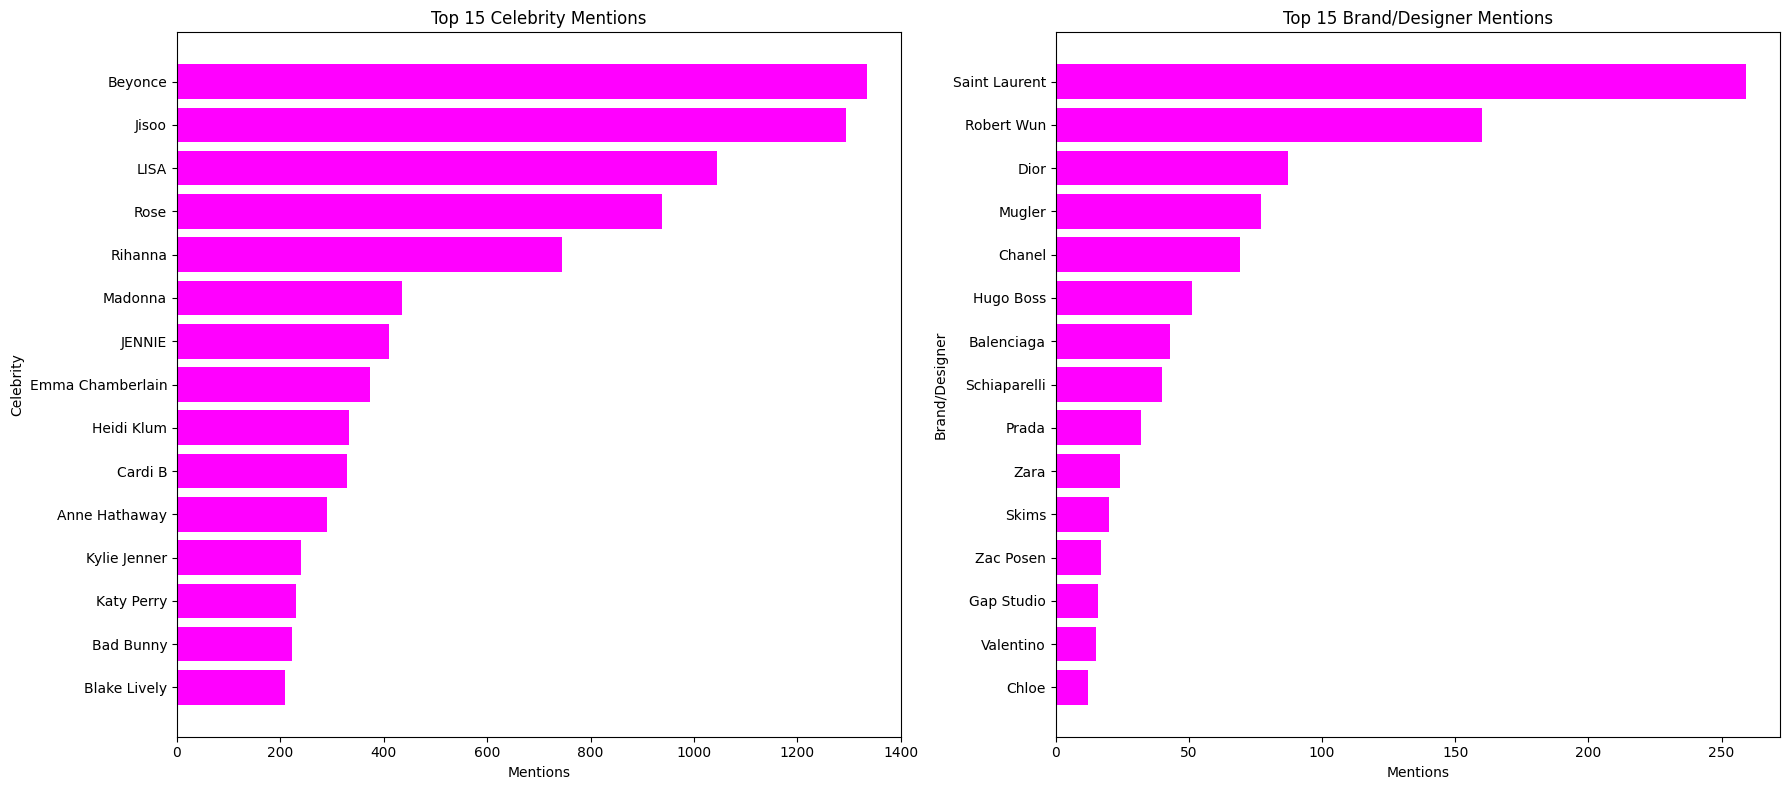

In [265]:

# Celebrity & Brand/Designer Summary
print("CELEBRITY OCCURRENCE SUMMARY")
print("=" * 80)
print(f"Total unique celebrities: {celeb_summary['total_unique']}")
print(f"Total celebrity mentions: {celeb_summary['total_mentions']}")
print(f"Mean mentions per celebrity: {celeb_summary['mean_mentions']:.2f}")
print(f"Median mentions per celebrity: {celeb_summary['median_mentions']:.2f}")
print(f"Max celebrity mentions: {celeb_summary['max_mentions']}")
print()
print("BRAND/DESIGNER OCCURRENCE SUMMARY")
print("=" * 80)
print(f"Total unique brands/designers: {brand_summary['total_unique']}")
print(f"Total brand/designer mentions: {brand_summary['total_mentions']}")
print(f"Mean mentions per brand/designer: {brand_summary['mean_mentions']:.2f}")
print(f"Median mentions per brand/designer: {brand_summary['median_mentions']:.2f}")
print(f"Max brand/designer mentions: {brand_summary['max_mentions']}")
print()

# Prepare data for plots
top_celeb_mentions = sorted(celeb_occurrence_counter.items(), key=lambda item: item[1], reverse=True)[:TOP_ENTITY_COUNT]
top_celeb_mentions = list(reversed(top_celeb_mentions))
top_brand_mentions = sorted(brand_occurrence_counter.items(), key=lambda item: item[1], reverse=True)[:TOP_ENTITY_COUNT]
top_brand_mentions = list(reversed(top_brand_mentions))

# Make side by side plots
fig, (ax_celeb, ax_brand) = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

# Celebrity plot
ax_celeb.barh([item[0] for item in top_celeb_mentions], [item[1] for item in top_celeb_mentions], color=SENTIMENT_FREE_COLOR)
ax_celeb.set_title(f"Top {TOP_ENTITY_COUNT} Celebrity Mentions")
ax_celeb.set_xlabel("Mentions")
ax_celeb.set_ylabel("Celebrity")

# Brand/Designer plot
ax_brand.barh([item[0] for item in top_brand_mentions], [item[1] for item in top_brand_mentions], color=SENTIMENT_FREE_COLOR)
ax_brand.set_title(f"Top {TOP_ENTITY_COUNT} Brand/Designer Mentions")
ax_brand.set_xlabel("Mentions")
ax_brand.set_ylabel("Brand/Designer")

plt.tight_layout()
plt.show()


In [ ]:
MIN_CELEB_COUNT_THRESHOLD = math.ceil(celeb_summary["median_mentions"])

# Using median mentions produces less than 15 entities for brands
# MIN_BRAND_COUNT_THRESHOLD = math.ceil(brand_summary["median_mentions"])
MIN_BRAND_COUNT_THRESHOLD = 7


## 2. VADER


In [196]:


VADER_POSITIVE_THRESHOLD = 0.05
VADER_NEGATIVE_THRESHOLD = -0.05

VADER_SENTIMENT_FIELDS = [
    "vader_compound",
    "vader_sentiment",
]

BERT_SENTIMENT_FIELDS = [
    "bert_sentiment",
    "bert_sentiment_raw",
    "bert_confidence",
    "bert_negative",
    "bert_neutral",
    "bert_positive",
]

TOPIC_ANALYSIS_FIELDS = [
    "comment_text_topic",
    "comment_tokens_topic",
    "comment_text_topic_stemmed",
    "comment_tokens_topic_stemmed",
    "topic_token_count",
]

NETWORK_ANALYSIS_FIELDS = [
    "comment_id",
    "comment_author_id",
    "comment_author",
    "video_id",
    "channel_id",
    "comment_published_at",
    "comment_like_count",
    "is_reply",
    "parent_comment_id",
    "reply_to_author_id",
    "celebs",
    "brands",
]

REQUIRED_OUTPUT_FIELDS = []
REQUIRED_OUTPUT_FIELDS.extend(TOPIC_ANALYSIS_FIELDS)
REQUIRED_OUTPUT_FIELDS.extend(NETWORK_ANALYSIS_FIELDS)
REQUIRED_OUTPUT_FIELDS.extend(VADER_SENTIMENT_FIELDS)
REQUIRED_OUTPUT_FIELDS.extend(BERT_SENTIMENT_FIELDS)

In [197]:
def get_vader_label(compound_score):
    if compound_score >= VADER_POSITIVE_THRESHOLD:
        return "positive"
    if compound_score <= VADER_NEGATIVE_THRESHOLD:
        return "negative"
    return "neutral"

def vader_sentiment_analysis(processed_data):
    """
    Use VADER lexicon for sentiment analysis on processed YouTube comment data.

    @param processed_data: list of dicts with comment text and published date keys
    @returns: list of VADER sentiment result dicts, aligned to processed_data order
    """
    sent_analyser = SentimentIntensityAnalyzer()
    sentiment_results = []

    for entry in processed_data:
        vader_text = entry[SENTIMENT_TEXT_FIELD]
        post_date = entry.get("comment_published_at", None)
        scores = sent_analyser.polarity_scores(vader_text)
        compound_score = scores["compound"]

        sentiment_results.append({
            "comment_id": entry.get("comment_id"),
            "published_at": post_date,
            "vader_compound": compound_score,
            "vader_sentiment": get_vader_label(compound_score),
        })
    return sentiment_results


In [198]:
for row, result in zip(processed_data, vader_sentiment_analysis(processed_data)):
    row["vader_compound"] = result["vader_compound"]
    row["vader_sentiment"] = result["vader_sentiment"]


In [199]:
vader_sentiment = []
for row in processed_data:
    result = {
        "comment_id": row["comment_id"],
        "published_at": row.get("comment_published_at"),
        "vader_compound": row["vader_compound"],
        "vader_sentiment": row["vader_sentiment"],
    }
    vader_sentiment.append(result)

vader_series = pd.Series(
    [row["vader_compound"] for row in vader_sentiment if pd.notnull(row.get("published_at"))],
    index=pd.to_datetime([row["published_at"] for row in vader_sentiment if pd.notnull(row.get("published_at"))]),
)


In [200]:
print_sentiment_examples(processed_data, "vader_sentiment", "positive", "VADER")
print_sentiment_examples(processed_data, "vader_sentiment", "negative", "VADER")
print_sentiment_examples(processed_data, "vader_sentiment", "neutral", "VADER")

vader_sentiment_counter = Counter()
for row in processed_data:
    vader_sentiment_counter[row["vader_sentiment"]] += 1



VADER POSITIVE SENTIMENT EXAMPLES
- Free the CHILDREN
- Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤
- Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤
- Kardashians looking great, Mom, the head of the family wearing a fabulous Kimono, it's amazing. ❤❤❤
- Everyone looks outstanding, so much creative art and unique designs. I love Cher black outfit with her leather and bright shiny materials. Cher stands out always. ❤❤❤

VADER NEGATIVE SENTIMENT EXAMPLES
- When the Queen, Beyoncé showed up, the crowd went crazy! ❤❤❤❤❤❤❤❤❤❤
- We missed figure skater, cause those ladies are just talking and do not show all the dress show
- at 25;27 she is clearly embarrassed and wishes she had worn clothes..hand over her chest to cover up...
- Really didnt read the room before you took part in this narcofinancing cult circus did you Vogue. Enjoy those crisis meetings Anna
- Waste of money! People are hungry

VADER NEUTRAL SENTIMENT EXAMPLES
- The whole thing is so phoney STIFF UNNATURAL SMILES..s

### Overall Sentiment Distribution


VADER SENTIMENT SUMMARY
Analysed comments: 46829
Mean compound score: 0.1548
Median compound score: 0.0000
Standard deviation: 0.4584

Positive comments: 21,782 (46.51%)
Neutral comments: 14,273 (30.48%)
Negative comments: 10,774 (23.01%)


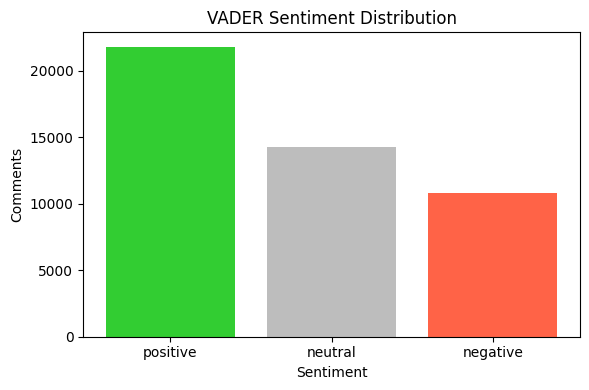

In [201]:
vader_sentiment_counter = Counter(row["vader_sentiment"] for row in processed_data)
total_vader_comments = len(processed_data)
positive_vader_percent = 100 * vader_sentiment_counter["positive"] / total_vader_comments if total_vader_comments else 0
neutral_vader_percent = 100 * vader_sentiment_counter["neutral"] / total_vader_comments if total_vader_comments else 0
negative_vader_percent = 100 * vader_sentiment_counter["negative"] / total_vader_comments if total_vader_comments else 0

print("VADER SENTIMENT SUMMARY")
print("=" * 80)
print(f"Analysed comments: {total_vader_comments}")
print(f"Mean compound score: {vader_series.mean():.4f}")
print(f"Median compound score: {vader_series.median():.4f}")
print(f"Standard deviation: {vader_series.std():.4f}\n")

print(f"Positive comments: {vader_sentiment_counter['positive']:,} ({positive_vader_percent:.2f}%)")
print(f"Neutral comments: {vader_sentiment_counter['neutral']:,} ({neutral_vader_percent:.2f}%)")
print(f"Negative comments: {vader_sentiment_counter['negative']:,} ({negative_vader_percent:.2f}%)")

sentiment_labels = ["positive", "neutral", "negative"]
sentiment_values = [vader_sentiment_counter.get(label, 0) for label in sentiment_labels]
sentiment_bar_colors = [SENTIMENT_COLORS[label] for label in sentiment_labels]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sentiment_labels, sentiment_values, color=sentiment_bar_colors)
ax.set_title("VADER Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Comments")
plt.tight_layout()


### Sentiment Over Time


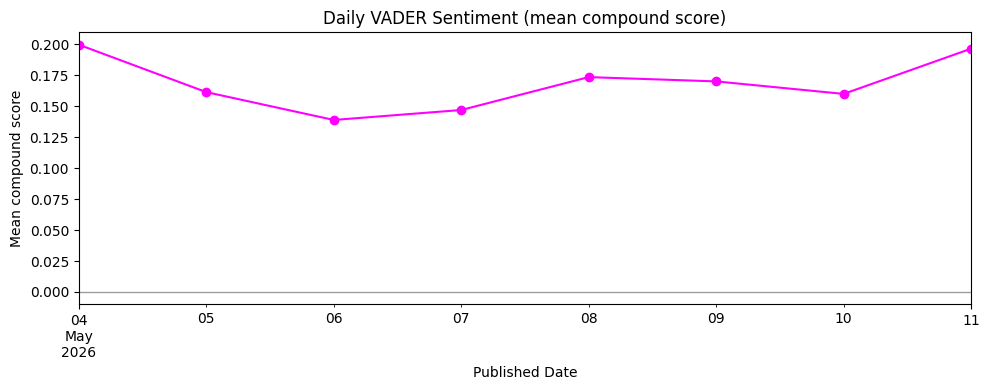

In [202]:
# Resample by day and plot
mean_daily_vader = vader_series.resample("D").mean()

plt.figure(figsize=(10, 4))
mean_daily_vader.plot(marker="o", color=SENTIMENT_FREE_COLOR)
plt.title("Daily VADER Sentiment (mean compound score)")
plt.xlabel("Published Date")
plt.ylabel("Mean compound score")
plt.axhline(0, color="#9e9e9e", linewidth=1)
plt.tight_layout()
plt.show()


In [236]:
vader_sentiment_df = pd.DataFrame(processed_data)

vader_celeb_rows = vader_sentiment_df.explode("celebs").dropna(subset=["celebs"]).reset_index(drop=True)
vader_brand_rows = vader_sentiment_df.explode("brands").dropna(subset=["brands"]).reset_index(drop=True)

vader_celeb_mention_totals = vader_celeb_rows.groupby("celebs").size()
vader_brand_mention_totals = vader_brand_rows.groupby("brands").size()

vader_celeb_sentiment_share = pd.crosstab(
    vader_celeb_rows["celebs"],
    vader_celeb_rows["vader_sentiment"],
    normalize="index",
).mul(100)[SENTIMENT_ORDER]
vader_brand_sentiment_share = pd.crosstab(
    vader_brand_rows["brands"],
    vader_brand_rows["vader_sentiment"],
    normalize="index",
).mul(100)[SENTIMENT_ORDER]

eligible_vader_celeb_sentiment_share = vader_celeb_sentiment_share.loc[vader_celeb_mention_totals[vader_celeb_mention_totals >= MIN_CELEB_COUNT_THRESHOLD].index]
eligible_vader_brand_sentiment_share = vader_brand_sentiment_share.loc[vader_brand_mention_totals[vader_brand_mention_totals >= MIN_BRAND_COUNT_THRESHOLD].index]

sentiment_colors = [SENTIMENT_COLORS[label] for label in SENTIMENT_ORDER]


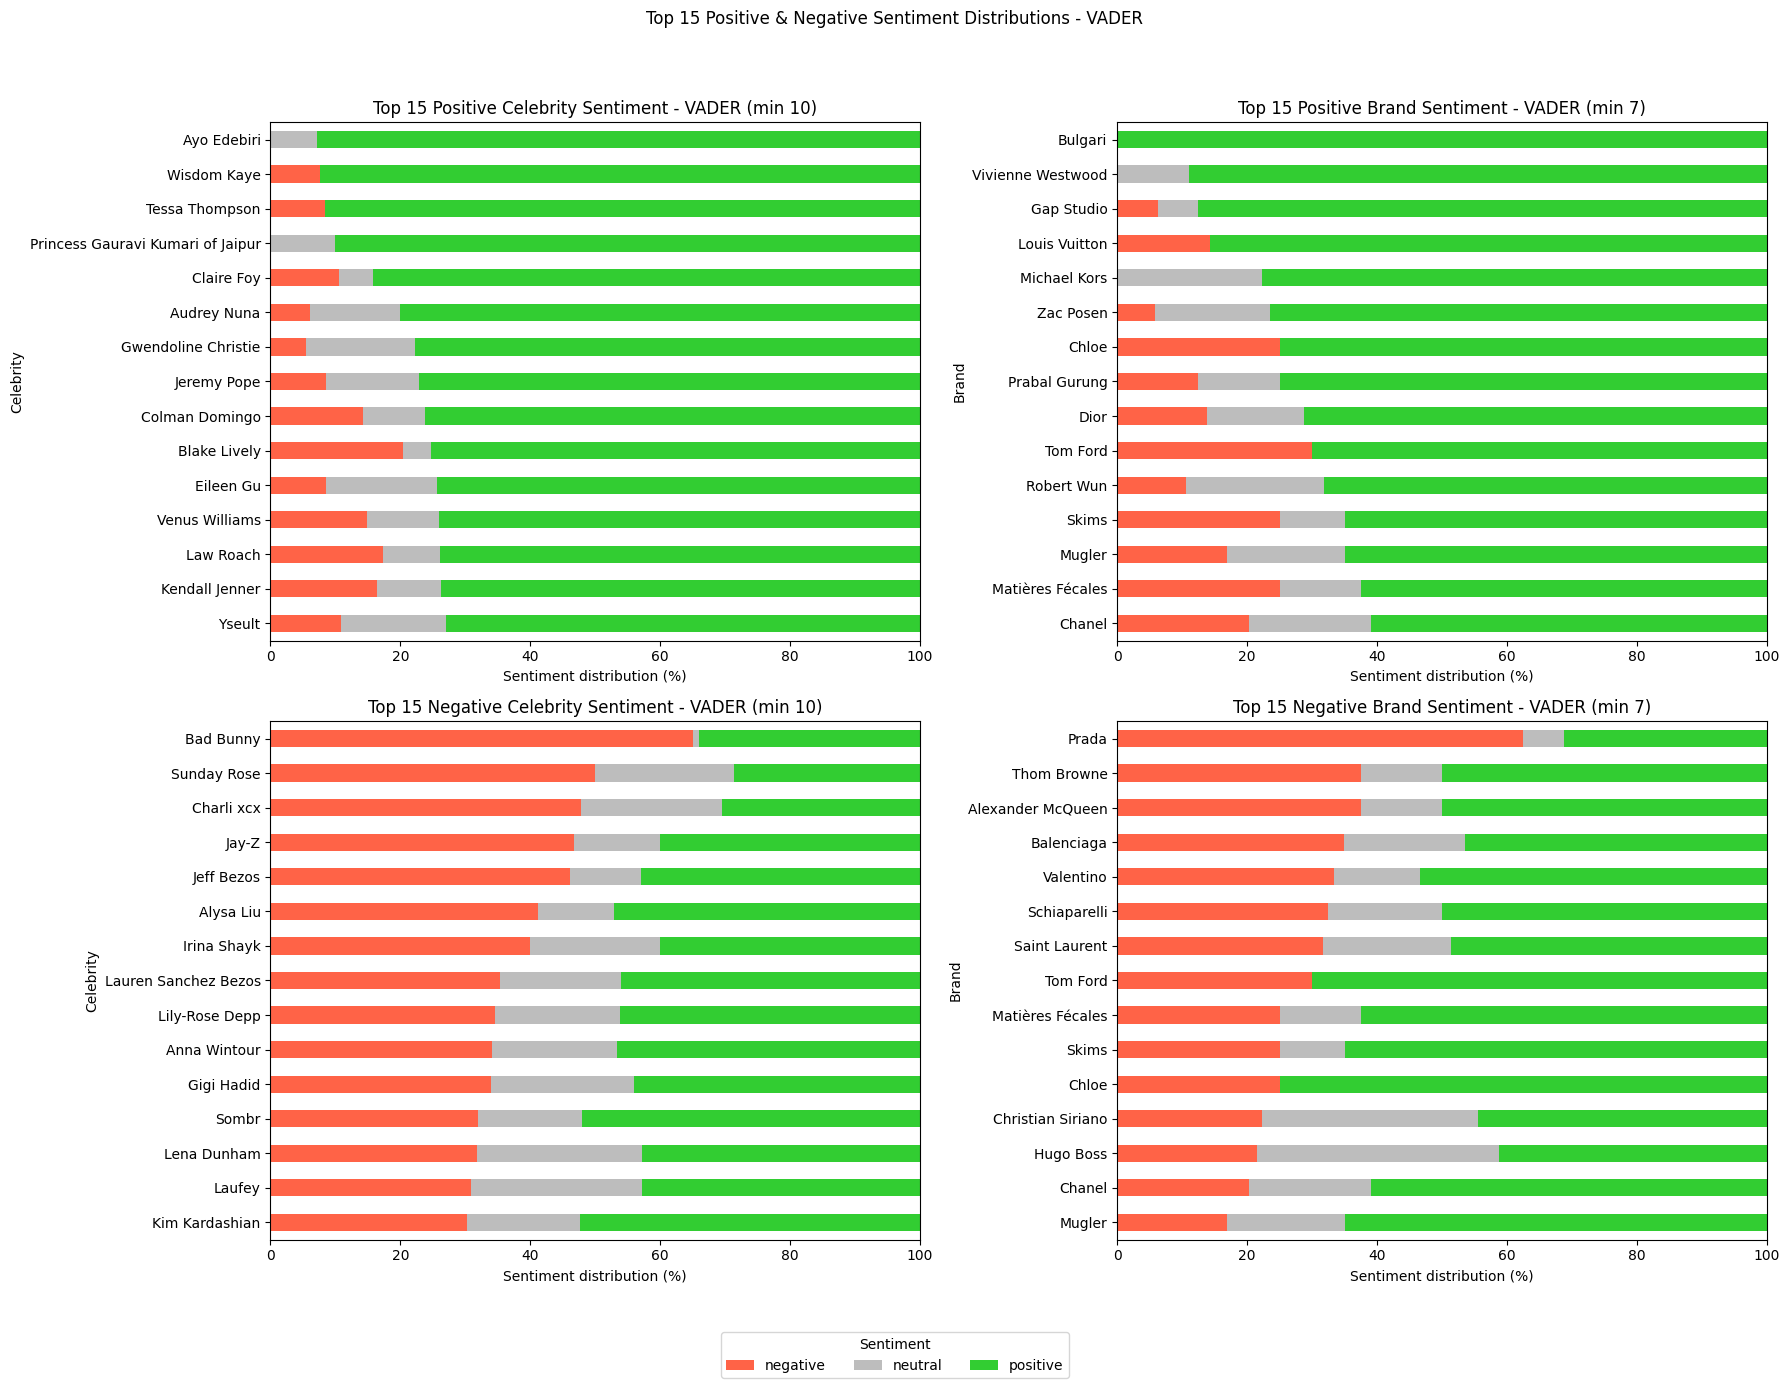

In [267]:
vader_top_positive_celebs = eligible_vader_celeb_sentiment_share["positive"].sort_values(ascending=False).head(TOP_ENTITY_COUNT).index
vader_top_positive_brands = eligible_vader_brand_sentiment_share["positive"].sort_values(ascending=False).head(TOP_ENTITY_COUNT).index
vader_positive_celeb_distribution = eligible_vader_celeb_sentiment_share.loc[vader_top_positive_celebs].sort_values("positive")
vader_positive_brand_distribution = eligible_vader_brand_sentiment_share.loc[vader_top_positive_brands].sort_values("positive")
vader_top_negative_celebs = eligible_vader_celeb_sentiment_share["negative"].sort_values(ascending=False).head(TOP_ENTITY_COUNT).index
vader_top_negative_brands = eligible_vader_brand_sentiment_share["negative"].sort_values(ascending=False).head(TOP_ENTITY_COUNT).index
vader_negative_celeb_distribution = eligible_vader_celeb_sentiment_share.loc[vader_top_negative_celebs].sort_values("negative")
vader_negative_brand_distribution = eligible_vader_brand_sentiment_share.loc[vader_top_negative_brands].sort_values("negative")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
vader_positive_celeb_distribution.plot(kind="barh", stacked=True, ax=axes[0, 0], color=sentiment_colors, title=f"Top {TOP_ENTITY_COUNT} Positive Celebrity Sentiment - VADER (min {MIN_CELEB_COUNT_THRESHOLD})")
vader_positive_brand_distribution.plot(kind="barh", stacked=True, ax=axes[0, 1], color=sentiment_colors, title=f"Top {TOP_ENTITY_COUNT} Positive Brand Sentiment - VADER (min {MIN_BRAND_COUNT_THRESHOLD})")
vader_negative_celeb_distribution.plot(kind="barh", stacked=True, ax=axes[1, 0], color=sentiment_colors, title=f"Top {TOP_ENTITY_COUNT} Negative Celebrity Sentiment - VADER (min {MIN_CELEB_COUNT_THRESHOLD})")
vader_negative_brand_distribution.plot(kind="barh", stacked=True, ax=axes[1, 1], color=sentiment_colors, title=f"Top {TOP_ENTITY_COUNT} Negative Brand Sentiment - VADER (min {MIN_BRAND_COUNT_THRESHOLD})")
[ax.set_xlabel("Sentiment distribution (%)") for ax in axes.flatten()]
axes[0, 0].set_ylabel("Celebrity")
axes[0, 1].set_ylabel("Brand")
axes[1, 0].set_ylabel("Celebrity")
axes[1, 1].set_ylabel("Brand")
[ax.set_xlim(0, 100) for ax in axes.flatten()]
handles, labels = axes[0, 0].get_legend_handles_labels()
[ax.get_legend().remove() for ax in axes.flatten()]
fig.legend(handles, labels, title="Sentiment", loc="lower center", ncol=len(labels))
fig.suptitle(f"Top {TOP_ENTITY_COUNT} Positive & Negative Sentiment Distributions - VADER", y=0.98)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()


## 3. RoBERTa


In [239]:
BERT_SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
BERT_SENTIMENT_MODEL_NAME = "cardiffnlp-twitter-roberta-base-sentiment-latest"
BERT_SENTIMENT_MODEL_DIR = PROJECT_ROOT / "models" / BERT_SENTIMENT_MODEL_NAME
HF_CACHE_DIR = PROJECT_ROOT / ".cache" / "huggingface"
BERT_CONFIDENCE_THRESHOLD = 0.65
BERT_BATCH_SIZE = 32


In [240]:

# Make model directory and download model if it doesn't exist
if not (BERT_SENTIMENT_MODEL_DIR / "config.json").exists():
    model = AutoModelForSequenceClassification.from_pretrained(BERT_SENTIMENT_MODEL)
    tokenizer = AutoTokenizer.from_pretrained(BERT_SENTIMENT_MODEL)
    BERT_SENTIMENT_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(BERT_SENTIMENT_MODEL_DIR)
    tokenizer.save_pretrained(BERT_SENTIMENT_MODEL_DIR)
    print(f"Downloaded and saved model to: {BERT_SENTIMENT_MODEL_DIR}")
else:
    print(f"Loaded model from: {BERT_SENTIMENT_MODEL_DIR}")


Loaded model from: /Users/cooper/Documents/GitHub/Network-Analysis-Project#/models/cardiffnlp-twitter-roberta-base-sentiment-latest


In [241]:
# Initialize the BERT-based sentiment analysis pipeline
sentiment_model = pipeline(
    "text-classification",
    model=str(BERT_SENTIMENT_MODEL_DIR),
    tokenizer=str(BERT_SENTIMENT_MODEL_DIR),
    return_all_scores=True,
    top_k=None,
    truncation=True,
    max_length=512,
    cache_dir=str(HF_CACHE_DIR),
)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 23767.45it/s]


In [242]:
def normalise_bert_label(label):
    """
    Map model labels to readable strings that match VADER sentiment labels.
    """
    label = label.lower()
    label_map = {
        "label_0": "negative",
        "label_1": "neutral",
        "label_2": "positive",
    }
    return label_map.get(label, label)


def bert_sentiment_analysis(processed_data, threshold=BERT_CONFIDENCE_THRESHOLD):
    """
    Use RoBERTa for sentiment analysis on processed YouTube comment data. 
    """
    texts = []
    for entry in processed_data:
        texts.append(entry.get(SENTIMENT_TEXT_FIELD, ""))

    bert_predictions = sentiment_model(texts, batch_size=BERT_BATCH_SIZE)
    sentiment_results = []

    for entry, scores in zip(processed_data, bert_predictions):
        scores_map = {}
        for score in scores:
            normalised_label = normalise_bert_label(score["label"])
            scores_map[normalised_label] = score["score"]

        top_label = max(scores_map, key=scores_map.get)
        confidence = scores_map[top_label]
        label = top_label if confidence >= threshold else "unknown"

        sentiment_results.append({
            "comment_id": entry.get("comment_id"),
            "bert_sentiment": label,
            "bert_sentiment_raw": top_label,
            "bert_confidence": round(confidence, 4),
            "bert_negative": round(scores_map.get("negative", 0.0), 4),
            "bert_neutral": round(scores_map.get("neutral", 0.0), 4),
            "bert_positive": round(scores_map.get("positive", 0.0), 4),
        })
    return sentiment_results


In [243]:
for row, result in zip(processed_data, bert_sentiment_analysis(processed_data)):
    for field in BERT_SENTIMENT_FIELDS:
        row[field] = result[field]

In [244]:
bert_sentiment = []
for row in processed_data:
    result = {
        "comment_id": row["comment_id"],
        "published_at": row.get("comment_published_at"),
        "bert_score": row["bert_positive"] - row["bert_negative"],
        "bert_sentiment": row["bert_sentiment"],
        "bert_sentiment_raw": row["bert_sentiment_raw"],
        "bert_confidence": row["bert_confidence"],
        "bert_negative": row["bert_negative"],
        "bert_neutral": row["bert_neutral"],
        "bert_positive": row["bert_positive"],
    }
    bert_sentiment.append(result)

bert_series = pd.Series(
    [row["bert_score"] for row in bert_sentiment if pd.notnull(row.get("published_at"))],
    index=pd.to_datetime([row["published_at"] for row in bert_sentiment if pd.notnull(row.get("published_at"))]),
)


In [245]:
celeb_counter_for_output = Counter()
brand_counter_for_output = Counter()

for row in processed_data:
    celebs = row.get("celebs", [])
    brands = row.get("brands", [])

    celeb_counter_for_output.update(celebs)
    brand_counter_for_output.update(brands)

sentiment_processed_video_data = processed_video_data.copy()
sentiment_processed_video_data["comments"] = processed_data
sentiment_processed_video_data["entity_counts"] = {
    "celebs": dict(celeb_counter_for_output),
    "brands": dict(brand_counter_for_output),
}


In [246]:
with open(SENTIMENT_PROCESSED_VIDEO_DATA_PATH, "w", encoding="utf-8") as f:
    json.dump(sentiment_processed_video_data, f, ensure_ascii=False, indent=2)

print(f"Saved sentiment processed data to {SENTIMENT_PROCESSED_VIDEO_DATA_PATH}")


Saved sentiment processed data to /Users/cooper/Documents/GitHub/Network-Analysis-Project#/data/video_data_sentiment_processed.json


In [247]:
print_sentiment_examples(processed_data, "bert_sentiment", "positive", "ROBERTA")
print_sentiment_examples(processed_data, "bert_sentiment", "negative", "ROBERTA")
print_sentiment_examples(processed_data, "bert_sentiment", "neutral", "ROBERTA")
print_sentiment_examples(processed_data, "bert_sentiment", "unknown", "ROBERTA")

bert_sentiment_counter = Counter()
for row in processed_data:
    bert_sentiment_counter[row["bert_sentiment"]] += 1



ROBERTA POSITIVE SENTIMENT EXAMPLES
- Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤
- Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤
- When the Queen, Beyoncé showed up, the crowd went crazy! ❤❤❤❤❤❤❤❤❤❤
- Beyonce art wear is extraordinary.❤❤❤
- Kardashians looking great, Mom, the head of the family wearing a fabulous Kimono, it's amazing. ❤❤❤

ROBERTA NEGATIVE SENTIMENT EXAMPLES
- The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..
- at 25;27 she is clearly embarrassed and wishes she had worn clothes..hand over her chest to cover up...
- Some beautiful fabrics, but I'm afraid I cannot understand anyone, and certainly not wealthy or famous women who believe that turning around to be admired while trying to appear nude or even being partly nude, is showing self-respect. Dressing well is important, but exposing too much is tacky, regardless of how expensive or fabulous the dress is. Ha

### Overall Sentiment Distribution


ROBERTA SENTIMENT SUMMARY
Analysed comments: 46829
Mean sentiment score: 0.0202
Median sentiment score: -0.0111
Standard deviation: 0.6960

Positive comments: 14,198 (30.32%)
Neutral comments: 7,332 (15.66%)
Negative comments: 13,161 (28.10%)
Unknown comments: 12,138 (25.92%)


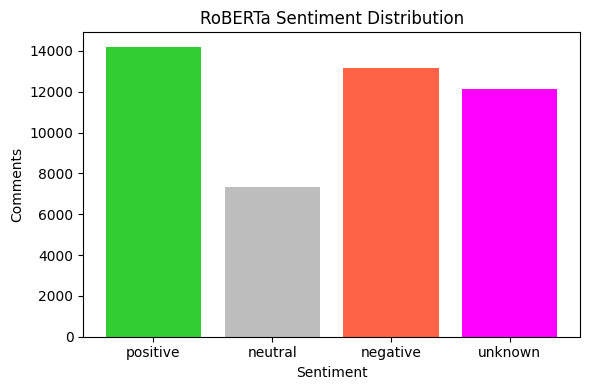

In [248]:
bert_sentiment_counter = Counter(row["bert_sentiment"] for row in processed_data)
total_bert_comments = len(processed_data)
positive_bert_percent = 100 * bert_sentiment_counter["positive"] / total_bert_comments if total_bert_comments else 0
neutral_bert_percent = 100 * bert_sentiment_counter["neutral"] / total_bert_comments if total_bert_comments else 0
negative_bert_percent = 100 * bert_sentiment_counter["negative"] / total_bert_comments if total_bert_comments else 0
unknown_bert_percent = 100 * bert_sentiment_counter["unknown"] / total_bert_comments if total_bert_comments else 0

print("ROBERTA SENTIMENT SUMMARY")
print("=" * 80)
print(f"Analysed comments: {total_bert_comments}")
print(f"Mean sentiment score: {bert_series.mean():.4f}")
print(f"Median sentiment score: {bert_series.median():.4f}")
print(f"Standard deviation: {bert_series.std():.4f}\n")

print(f"Positive comments: {bert_sentiment_counter['positive']:,} ({positive_bert_percent:.2f}%)")
print(f"Neutral comments: {bert_sentiment_counter['neutral']:,} ({neutral_bert_percent:.2f}%)")
print(f"Negative comments: {bert_sentiment_counter['negative']:,} ({negative_bert_percent:.2f}%)")
print(f"Unknown comments: {bert_sentiment_counter['unknown']:,} ({unknown_bert_percent:.2f}%)")

bert_sentiment_labels = ["positive", "neutral", "negative", "unknown"]
bert_sentiment_values = [bert_sentiment_counter.get(label, 0) for label in bert_sentiment_labels]
bert_sentiment_bar_colors = [SENTIMENT_COLORS.get(label, SENTIMENT_FREE_COLOR) for label in bert_sentiment_labels]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(bert_sentiment_labels, bert_sentiment_values, color=bert_sentiment_bar_colors)
ax.set_title("RoBERTa Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Comments")
plt.tight_layout()


### Entity-Level Sentiment


In [250]:
bert_sentiment_df = pd.DataFrame(processed_data)

bert_celeb_rows = bert_sentiment_df.explode("celebs").dropna(subset=["celebs"]).reset_index(drop=True)
bert_brand_rows = bert_sentiment_df.explode("brands").dropna(subset=["brands"]).reset_index(drop=True)
bert_known_celeb_rows = bert_celeb_rows[bert_celeb_rows["bert_sentiment"].isin(SENTIMENT_ORDER)]
bert_known_brand_rows = bert_brand_rows[bert_brand_rows["bert_sentiment"].isin(SENTIMENT_ORDER)]

bert_celeb_mention_totals = bert_celeb_rows.groupby("celebs").size()
bert_brand_mention_totals = bert_brand_rows.groupby("brands").size()

bert_celeb_sentiment_share = pd.crosstab(
    bert_known_celeb_rows["celebs"],
    bert_known_celeb_rows["bert_sentiment"],
    normalize="index",
).mul(100).reindex(index=bert_celeb_mention_totals.index, columns=SENTIMENT_ORDER, fill_value=0)
bert_brand_sentiment_share = pd.crosstab(
    bert_known_brand_rows["brands"],
    bert_known_brand_rows["bert_sentiment"],
    normalize="index",
).mul(100).reindex(index=bert_brand_mention_totals.index, columns=SENTIMENT_ORDER, fill_value=0)

eligible_bert_celeb_sentiment_share = bert_celeb_sentiment_share.loc[bert_celeb_mention_totals[bert_celeb_mention_totals >= MIN_CELEB_COUNT_THRESHOLD].index]
eligible_bert_brand_sentiment_share = bert_brand_sentiment_share.loc[bert_brand_mention_totals[bert_brand_mention_totals >= MIN_BRAND_COUNT_THRESHOLD].index]

sentiment_colors = [SENTIMENT_COLORS[label] for label in SENTIMENT_ORDER]


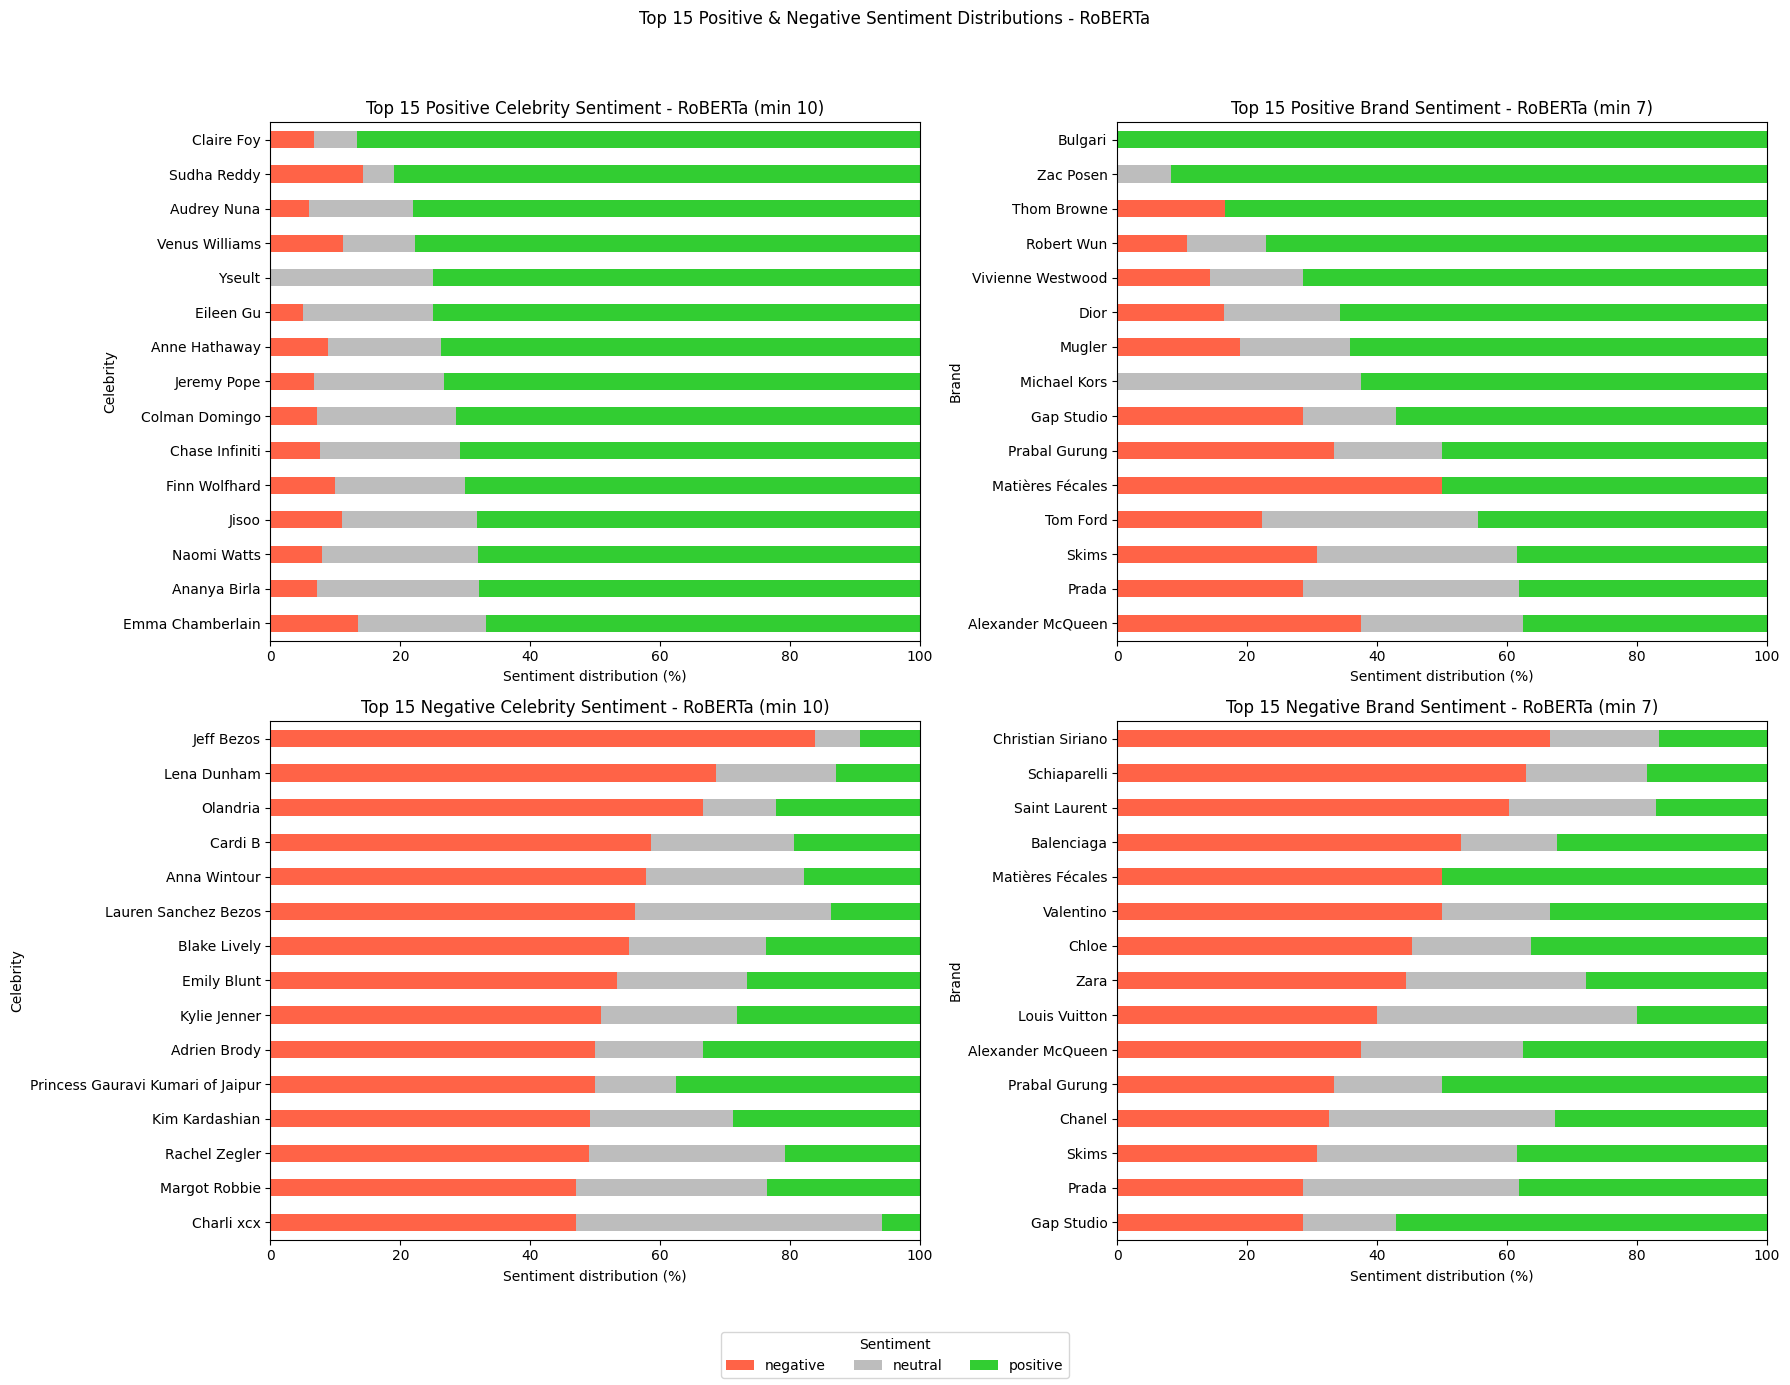

In [273]:
bert_top_positive_celebs = eligible_bert_celeb_sentiment_share["positive"].sort_values(ascending=False).head(TOP_ENTITY_COUNT).index
bert_top_positive_brands = eligible_bert_brand_sentiment_share["positive"].sort_values(ascending=False).head(TOP_ENTITY_COUNT).index
bert_positive_celeb_distribution = eligible_bert_celeb_sentiment_share.loc[bert_top_positive_celebs].sort_values("positive")
bert_positive_brand_distribution = eligible_bert_brand_sentiment_share.loc[bert_top_positive_brands].sort_values("positive")
bert_top_negative_celebs = eligible_bert_celeb_sentiment_share["negative"].sort_values(ascending=False).head(TOP_ENTITY_COUNT).index
bert_top_negative_brands = eligible_bert_brand_sentiment_share["negative"].sort_values(ascending=False).head(TOP_ENTITY_COUNT).index
bert_negative_celeb_distribution = eligible_bert_celeb_sentiment_share.loc[bert_top_negative_celebs].sort_values("negative")
bert_negative_brand_distribution = eligible_bert_brand_sentiment_share.loc[bert_top_negative_brands].sort_values("negative")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
bert_positive_celeb_distribution.plot(kind="barh", stacked=True, ax=axes[0, 0], color=sentiment_colors, title=f"Top {TOP_ENTITY_COUNT} Positive Celebrity Sentiment - RoBERTa (min {MIN_CELEB_COUNT_THRESHOLD})")
bert_positive_brand_distribution.plot(kind="barh", stacked=True, ax=axes[0, 1], color=sentiment_colors, title=f"Top {TOP_ENTITY_COUNT} Positive Brand Sentiment - RoBERTa (min {MIN_BRAND_COUNT_THRESHOLD})")
bert_negative_celeb_distribution.plot(kind="barh", stacked=True, ax=axes[1, 0], color=sentiment_colors, title=f"Top {TOP_ENTITY_COUNT} Negative Celebrity Sentiment - RoBERTa (min {MIN_CELEB_COUNT_THRESHOLD})")
bert_negative_brand_distribution.plot(kind="barh", stacked=True, ax=axes[1, 1], color=sentiment_colors, title=f"Top {TOP_ENTITY_COUNT} Negative Brand Sentiment - RoBERTa (min {MIN_BRAND_COUNT_THRESHOLD})")
[ax.set_xlabel("Sentiment distribution (%)") for ax in axes.flatten()]
axes[0, 0].set_ylabel("Celebrity")
axes[0, 1].set_ylabel("Brand")
axes[1, 0].set_ylabel("Celebrity")
axes[1, 1].set_ylabel("Brand")
[ax.set_xlim(0, 100) for ax in axes.flatten()]
handles, labels = axes[0, 0].get_legend_handles_labels()
[ax.get_legend().remove() for ax in axes.flatten()]
fig.legend(handles, labels, title="Sentiment", loc="lower center", ncol=len(labels))
fig.suptitle(f"Top {TOP_ENTITY_COUNT} Positive & Negative Sentiment Distributions - RoBERTa", y=0.98)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()


In [253]:
# Find all rows where matches occurred between methods and return final set of rows
matching_rows = []
non_matching_rows = []
for row in processed_data:
    if row["bert_sentiment"] == row["vader_sentiment"]:
        matching_rows.append(row)
    elif row["bert_sentiment"] != row["vader_sentiment"] and row["bert_sentiment"] != "unknown":
        non_matching_rows.append(row)


In [254]:
non_matching_counter = Counter()
for row in non_matching_rows:
    non_matching_counter[row["bert_sentiment"]] += 1

matching_counter = Counter()
for row in matching_rows:
    matching_counter[row["bert_sentiment"]] += 1


In [255]:

print_sentiment_distribution(matching_counter, len(matching_rows), "MATCHING SENTIMENT CLASSIFICATIONS")


MATCHING SENTIMENT CLASSIFICATIONS
Analysed comments: 22324
positive: 10,566 (47.33%)
negative: 7,068 (31.66%)
neutral: 4,690 (21.01%)


In [256]:

print_sentiment_distribution(non_matching_counter, len(non_matching_rows), "NON-MATCHING SENTIMENT CLASSIFICATIONS")


NON-MATCHING SENTIMENT CLASSIFICATIONS
Analysed comments: 12367
negative: 6,093 (49.27%)
positive: 3,632 (29.37%)
neutral: 2,642 (21.36%)


In [257]:
RANDOM_NON_MATCHING_ROWS = 5
random.seed(42)
random_non_matching_rows = random.sample(non_matching_rows, RANDOM_NON_MATCHING_ROWS)
print("RANDOM NON-MATCHING SENTIMENT CLASSIFICATIONS")
print("=" * 80)
for non_matching_row in random_non_matching_rows:
    print(f"VADER: {non_matching_row['vader_sentiment']}")
    print(f"BERT: {non_matching_row['bert_sentiment']}")
    print(f"Comment: {non_matching_row['comment_text_sentiment_analysis']}")
    print("-" * 80)


RANDOM NON-MATCHING SENTIMENT CLASSIFICATIONS
VADER: neutral
BERT: positive
Comment: At least the South Asian contingent brought ART to the Fashion Is Art themed gala.
--------------------------------------------------------------------------------
VADER: positive
BERT: negative
Comment: But when other people wear other shapes, you also laugh at them, Halloween, ghosts from the future, stiff sticks, four legs boogies... What do you want from them? Full nudity like you watching porn????
--------------------------------------------------------------------------------
VADER: neutral
BERT: positive
Comment: the daughter mother duo ❤️
--------------------------------------------------------------------------------
VADER: neutral
BERT: negative
Comment: ​ also the proportions are soooo off
--------------------------------------------------------------------------------
VADER: negative
BERT: neutral
Comment: Katy's mirror mask was referencing the mannequin heads in the exhibit, no?
----------

In [258]:
print_sentiment_examples(matching_rows, "bert_sentiment", "positive", "MATCHING VADER/BERT")
print_sentiment_examples(matching_rows, "bert_sentiment", "negative", "MATCHING VADER/BERT")
print_sentiment_examples(matching_rows, "bert_sentiment", "neutral", "MATCHING VADER/BERT")



MATCHING VADER/BERT POSITIVE SENTIMENT EXAMPLES
- Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤
- Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤
- Kardashians looking great, Mom, the head of the family wearing a fabulous Kimono, it's amazing. ❤❤❤
- Everyone looks outstanding, so much creative art and unique designs. I love Cher black outfit with her leather and bright shiny materials. Cher stands out always. ❤❤❤
- West African Doechi representing "dark female energy" is superb. I love her unique outfit.❤❤❤

MATCHING VADER/BERT NEGATIVE SENTIMENT EXAMPLES
- at 25;27 she is clearly embarrassed and wishes she had worn clothes..hand over her chest to cover up...
- Really didnt read the room before you took part in this narcofinancing cult circus did you Vogue. Enjoy those crisis meetings Anna
- Waste of money! People are hungry
- or you put the millions up to feed the homeless and Starving children? instead lets all dress us and take photos of each other? FREAKIN STUPID !
- Waste

## 4. Matching or Non-matching


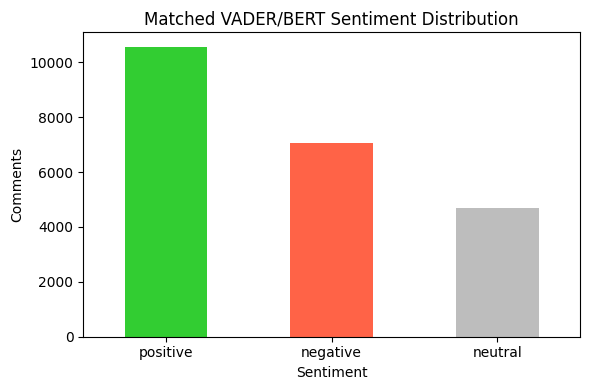

In [259]:
# Matching sentiment dataframe
matching_sentiment_df = pd.DataFrame(matching_rows).copy()

# Convert comment_published_at to datetime with error handling
matching_sentiment_df["comment_published_at"] = pd.to_datetime(matching_sentiment_df["comment_published_at"], errors="coerce")

# Count how many comments fall into each matched sentiment category
matching_sentiment_counts = matching_sentiment_df["bert_sentiment"].value_counts()

matching_sentiment_bar_colors = []
for label in matching_sentiment_counts.index:
    matching_sentiment_bar_colors.append(SENTIMENT_COLORS.get(label, SENTIMENT_FREE_COLOR))

fig, ax = plt.subplots(figsize=(6, 4))
ax = matching_sentiment_counts.plot(
    kind="bar",
    ax=ax,
    color=matching_sentiment_bar_colors,
    rot=0,
    title="Matched VADER/BERT Sentiment Distribution",
)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Comments")
plt.tight_layout()


### Agreement-Only Sentiment Over Time


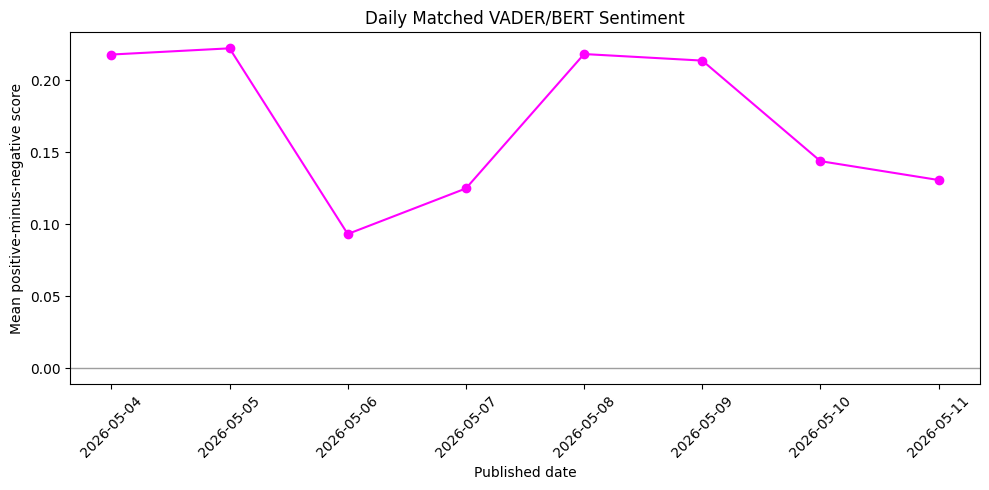

In [260]:
matching_sentiment_over_time_df = matching_sentiment_df.dropna(subset=["comment_published_at"]).copy()
matching_sentiment_over_time_df["published_date"] = matching_sentiment_over_time_df["comment_published_at"].dt.date
matching_sentiment_over_time_df["matching_sentiment_score"] = matching_sentiment_over_time_df["bert_positive"] - matching_sentiment_over_time_df["bert_negative"]

daily_matching_sentiment = matching_sentiment_over_time_df.groupby("published_date")["matching_sentiment_score"].mean().reset_index(name="mean_sentiment")
daily_matching_sentiment["published_date"] = daily_matching_sentiment["published_date"].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(daily_matching_sentiment["published_date"], daily_matching_sentiment["mean_sentiment"], marker="o", color=SENTIMENT_FREE_COLOR)
ax.set_title("Daily Matched VADER/BERT Sentiment")
ax.set_xlabel("Published date")
ax.set_ylabel("Mean positive-minus-negative score")
ax.axhline(0, color="#9e9e9e", linewidth=1)
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()


### Agreement-Only Sentiment by Entity


In [261]:
matching_celeb_rows = matching_sentiment_df.explode("celebs").dropna(subset=["celebs"]).reset_index(drop=True)
matching_brand_rows = matching_sentiment_df.explode("brands").dropna(subset=["brands"]).reset_index(drop=True)

matching_celeb_mention_totals = matching_celeb_rows.groupby("celebs").size()
matching_brand_mention_totals = matching_brand_rows.groupby("brands").size()

matching_celeb_sentiment_share = pd.crosstab(
    matching_celeb_rows["celebs"],
    matching_celeb_rows["bert_sentiment"],
    normalize="index",
).mul(100).reindex(columns=SENTIMENT_ORDER, fill_value=0)
matching_brand_sentiment_share = pd.crosstab(
    matching_brand_rows["brands"],
    matching_brand_rows["bert_sentiment"],
    normalize="index",
).mul(100).reindex(columns=SENTIMENT_ORDER, fill_value=0)

eligible_matching_celeb_sentiment_share = matching_celeb_sentiment_share.loc[matching_celeb_mention_totals[matching_celeb_mention_totals >= MIN_CELEB_COUNT_THRESHOLD].index]
eligible_matching_brand_sentiment_share = matching_brand_sentiment_share.loc[matching_brand_mention_totals[matching_brand_mention_totals >= MIN_BRAND_COUNT_THRESHOLD].index]

sentiment_colors = [SENTIMENT_COLORS[label] for label in SENTIMENT_ORDER]


In [ ]:
matching_top_positive_celebs = eligible_matching_celeb_sentiment_share["positive"].sort_values(ascending=False).head(TOP_ENTITY_COUNT).index
matching_top_positive_brands = eligible_matching_brand_sentiment_share["positive"].sort_values(ascending=False).head(TOP_ENTITY_COUNT).index
matching_positive_celeb_distribution = eligible_matching_celeb_sentiment_share.loc[matching_top_positive_celebs].sort_values("positive")
matching_positive_brand_distribution = eligible_matching_brand_sentiment_share.loc[matching_top_positive_brands].sort_values("positive")
matching_top_negative_celebs = eligible_matching_celeb_sentiment_share["negative"].sort_values(ascending=False).head(TOP_ENTITY_COUNT).index
matching_top_negative_brands = eligible_matching_brand_sentiment_share["negative"].sort_values(ascending=False).head(TOP_ENTITY_COUNT).index
matching_negative_celeb_distribution = eligible_matching_celeb_sentiment_share.loc[matching_top_negative_celebs].sort_values("negative")
matching_negative_brand_distribution = eligible_matching_brand_sentiment_share.loc[matching_top_negative_brands].sort_values("negative")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
matching_positive_celeb_distribution.plot(kind="barh", stacked=True, ax=axes[0, 0], color=sentiment_colors, title=f"Top {TOP_ENTITY_COUNT} Positive Celebrity Sentiment - Matched VADER/BERT (min {MIN_CELEB_COUNT_THRESHOLD})")
matching_positive_brand_distribution.plot(kind="barh", stacked=True, ax=axes[0, 1], color=sentiment_colors, title=f"Top {TOP_ENTITY_COUNT} Positive Brand Sentiment - Matched VADER/BERT (min {MIN_BRAND_COUNT_THRESHOLD})")
matching_negative_celeb_distribution.plot(kind="barh", stacked=True, ax=axes[1, 0], color=sentiment_colors, title=f"Top {TOP_ENTITY_COUNT} Negative Celebrity Sentiment - Matched VADER/BERT (min {MIN_CELEB_COUNT_THRESHOLD})")
matching_negative_brand_distribution.plot(kind="barh", stacked=True, ax=axes[1, 1], color=sentiment_colors, title=f"Top {TOP_ENTITY_COUNT} Negative Brand Sentiment - Matched VADER/BERT (min {MIN_BRAND_COUNT_THRESHOLD})")
[ax.set_xlabel("Sentiment distribution (%)") for ax in axes.flatten()]
axes[0, 0].set_ylabel("Celebrity")
axes[0, 1].set_ylabel("Brand")
axes[1, 0].set_ylabel("Celebrity")
axes[1, 1].set_ylabel("Brand")
[ax.set_xlim(0, 100) for ax in axes.flatten()]
handles, labels = axes[0, 0].get_legend_handles_labels()
[ax.get_legend().remove() for ax in axes.flatten()]
fig.legend(handles, labels, title="Sentiment", loc="lower center", ncol=len(labels))
fig.suptitle(f"Top {TOP_ENTITY_COUNT} Positive & Negative Sentiment Distributions - Matched VADER/BERT", y=0.98)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()
